In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("INFO")

[2025年04月24日 16时42分15秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

## 数据

In [2]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("/home/huang/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad")
fadata = cfe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"

sc.pp.subsample(fadata, n_obs=500)

fadata

AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [3]:
import pandas as pd

# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
    ],
    columns=["from", "to"],
)

fadata.add_trajectory_mannually(milestone_network)

AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'milestone_color', 'milestone'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'milestone_colors', 'milestone_color_colors', 'milestone_color_dict'
    obsm: 'X_pca', 'X_umap', 'milestone_network_emb'
    layers: 'spliced', 'unspliced', 'expression', 'count'

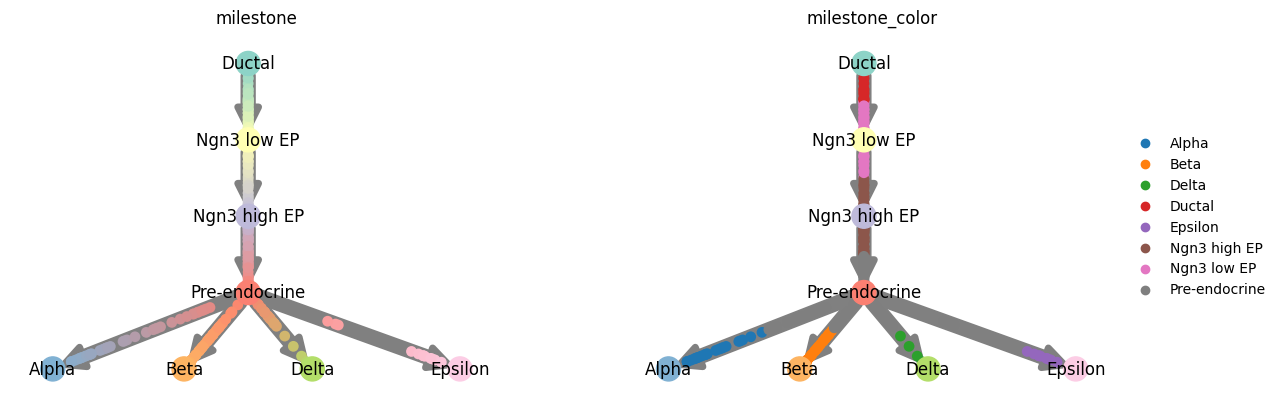

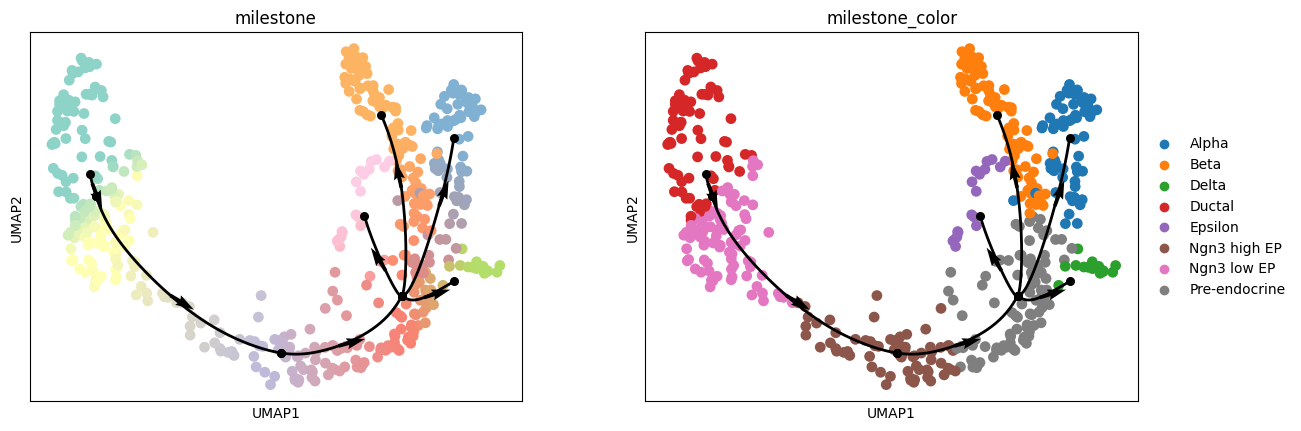

In [4]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key)  # new cluster color

cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)
fadata

Method and plot

In [5]:
# TODO: PAGA need to be optimized, disconnected graph
prior_information = {"start_id": fadata.obs.index[0], "groups_id": fadata.obs[cluster_key].tolist()}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata


# method_name_list = ["paga", "comp1", "angle", "state_comp", "cluster_mst", "projection_mst", "graph_mst", "scvelo"]
# method_name_list = ["comp1", "angle", "state_comp", "cluster_mst", "projection_mst", "graph_mst"]
method_name_list = ["comp1", "angle", "state_comp"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)

    method.infer_trajectory(fadata)

    # cfe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)

[2025年04月24日 16时42分20秒] INFO     Loaded function: <function cf_comp1 at 0x723e6f10a200> from                 
                                       /home/mhn/Code/CellFateExplorer/cfe/method/function/cf_comp1.py             
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x723e5889d2d0>                                                                   
[2025年04月24日 16时42分21秒] INFO     Loaded function: <function cf_angle at 0x723e5ceba4d0> from                 
                                       /home/mhn/Code/CellFateExplorer/cfe/method/function/cf_angle.py             
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x723e5889c6d0>                                                                   
                        INFO     Loaded function: <function cf_state_comp at 0x723e5

In [ ]:
fadata.trajectory_history_dict["ref"]

AttributeError: 'dict' object has no attribute '__dict__'

## 指标

In [6]:
parsed_model_name_list = fadata.get_all_model_name()  # 解析后的模型名称
model_name_list = fadata.get_all_model_name(parse=False)
parsed_model_name_list, model_name_list

                        WARNING  'ref' is not a valid random_time_string, don't need parse                         


(['ref',
  'comp1-python_function',
  'angle-python_function',
  'state_comp-python_function'],
 ['ref',
  '20250424_164220__comp1-python_function__UgB0UUEc9K',
  '20250424_164221__angle-python_function__pTRMc1E9zy',
  '20250424_164221__state_comp-python_function__afbc7Om84S'])

In [7]:
fadata.uns["cfe"]["trajectory_history_dict"]

{}

In [8]:
fadata.trajectory_history_dict

{'ref': {'milestone_wrapper': <cfe.data.fate_milestone_wrapper.MilestoneWrapper at 0x723f201477f0>,
  'raw_wrapper_dict': {},
  'waypoint_wrapper': <cfe.data.fate_waypoint_wrapper.WaypointWrapper at 0x723e5d181630>},
 '20250424_164220__comp1-python_function__UgB0UUEc9K': {'milestone_wrapper': <cfe.data.fate_milestone_wrapper.MilestoneWrapper at 0x723e6f027850>,
  'raw_wrapper_dict': {}},
 '20250424_164221__angle-python_function__pTRMc1E9zy': {'milestone_wrapper': <cfe.data.fate_milestone_wrapper.MilestoneWrapper at 0x723e5889e920>,
  'raw_wrapper_dict': {'pseudotime': array([-1.13691910e+02,  2.56335239e+01, -2.51792336e+00, -1.20978760e+02,
           2.00083115e+02,  2.16873215e+02,  8.85132980e+00, -9.10803146e+01,
          -1.30153793e+02, -1.35317398e+02, -1.97504822e+02, -5.01548386e+01,
          -1.10150307e+02, -6.79574509e+01, -1.09601219e+02,  1.88902573e+02,
           6.59437256e+02, -7.90659485e+01,  3.15972534e+02, -1.10572052e+02,
          -9.56471176e+01, -3.24102859

In [9]:
metrics = cfe.metric.metrics
metric_id_list = metrics[metrics["category"] == "topology"]["metric_id"].tolist()
metric_id_list

['edge_flip', 'him', 'isomorphic']

In [10]:
import pandas as pd


model_metric_dict = {}

for model_name in model_name_list:
    if "angle-python_function" not in model_name:  # angle模型
        model_metric = cfe.metric.calculate_metrics(
            fadata, metrics=metric_id_list, now_model=model_name, ref_model="ref"
        )
        model_metric_dict[model_name] = model_metric

df = pd.DataFrame(model_metric_dict).T
df

,isomorphic,edge_flip,him
ref,1.0,1.0,1.000000
20250424_164220__comp1-python_function__UgB0UUEc9K,0.0,0.0,0.272876
20250424_164221__state_comp-python_function__afbc7Om84S,0.0,0.4,0.212602


In [11]:
fadata.uns["cfe"]["trajectory_history_dict"]

{}

In [12]:
adata

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'

In [13]:
adata.obs

,clusters_coarse,clusters,S_score,G2M_score
index,,,,
AAACCTGAGAGGGATA,Pre-endocrine,Pre-endocrine,-0.224902,-0.252071
AAACCTGAGCCTTGAT,Ductal,Ductal,-0.014707,-0.232610
AAACCTGAGGCAATTA,Endocrine,Alpha,-0.171255,-0.286834
AAACCTGCATCATCCC,Ductal,Ductal,0.599244,0.191243
AAACCTGGTAAGTGGC,Ngn3 high EP,Ngn3 high EP,-0.179981,-0.126030
...,...,...,...,...
TTTGTCAAGTGACATA,Pre-endocrine,Pre-endocrine,-0.235896,-0.266101
TTTGTCAAGTGTGGCA,Ngn3 high EP,Ngn3 high EP,0.279374,-0.204047
TTTGTCAGTTGTTTGG,Ductal,Ductal,-0.045692,-0.208907
